In [51]:
import pandas as pd
import numpy as np
import re
import math
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df = pd.read_csv("/content/data.csv", engine="python", on_bad_lines="skip")

df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669640 entries, 0 to 669639
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   password  669639 non-null  object
 1   strength  669640 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 10.2+ MB


In [53]:
# Remove missing values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

# Remove extra spaces
df["password"] = df["password"].str.strip()

# Remove very short passwords
df = df[df["password"].str.len() >= 4]

In [54]:
def extract_features(p):
    return pd.Series({
        "length": len(p),
        "upper": sum(1 for c in p if c.isupper()),
        "lower": sum(1 for c in p if c.islower()),
        "digits": sum(1 for c in p if c.isdigit()),
        "special": len(re.findall(r'[^a-zA-Z0-9]', p)),
        "unique_chars": len(set(p)),
    })

features = df["password"].apply(extract_features)
df = pd.concat([df, features], axis=1)

In [55]:
# Entropy
def calculate_entropy(p):
    prob = [p.count(c) / len(p) for c in set(p)]
    return -sum([p * math.log2(p) for p in prob])

df["entropy"] = df["password"].apply(calculate_entropy)

# Sequence detection
def has_sequence(p):
    sequences = ["123", "234", "345", "abc", "bcd", "cde"]
    return int(any(seq in p.lower() for seq in sequences))

df["has_sequence"] = df["password"].apply(has_sequence)

# Common patterns
common_patterns = [
    "password", "admin", "qwerty", "letmein",
    "welcome", "1234", "12345", "abc123", "iloveyou"
]

def check_common(p):
    return int(any(pattern in p.lower() for pattern in common_patterns))

df["common_pattern"] = df["password"].apply(check_common)

In [56]:
df = df[df["password"].str.len().between(4, 16)]

df = df[
    ~df["password"].str.match(r'^[0-9]+$') &
    ~df["password"].str.match(r'^[a-zA-Z]+$') &
    ~df["password"].str.match(r'^(.)\1+$')
]

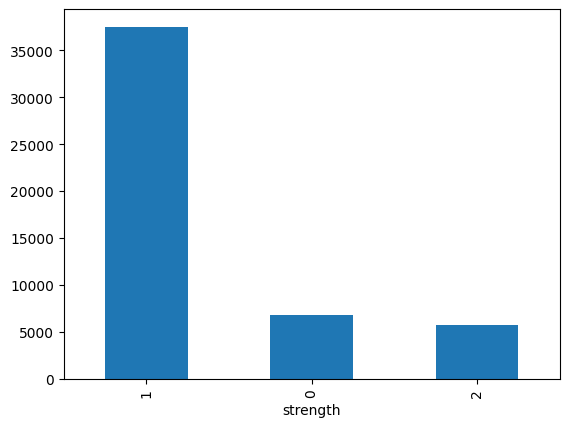

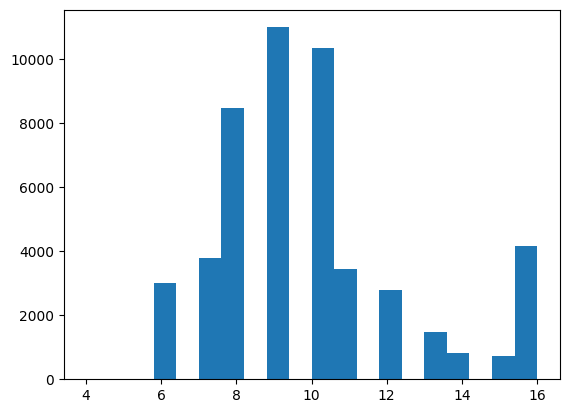

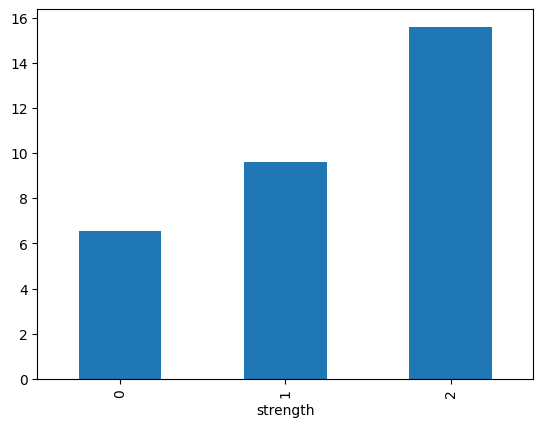

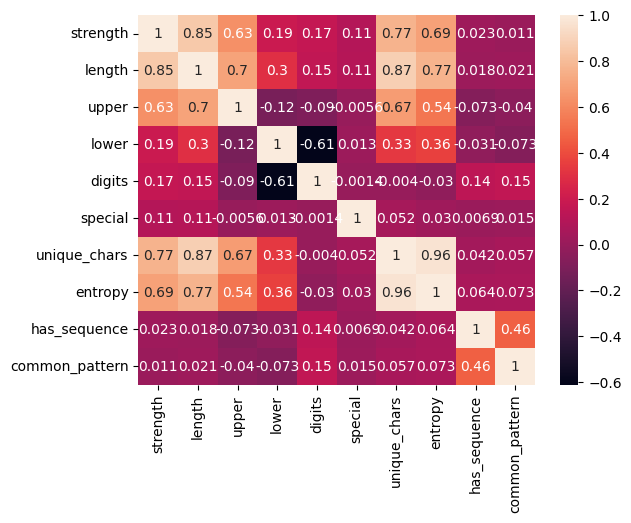

In [57]:
sample_df = df.sample(50000, random_state=42)

sample_df["strength"].value_counts().plot(kind="bar")
plt.show()

plt.hist(sample_df["length"], bins=20)
plt.show()

sample_df.groupby("strength")["length"].mean().plot(kind="bar")
plt.show()

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [58]:
# Move 'strength' to last column
cols = [col for col in df.columns if col != "strength"] + ["strength"]
df = df[cols]

df.to_csv("cleaned_password_dataset.csv", index=False)

In [59]:
#Random Forest Classifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("/content/cleaned_password_dataset.csv")

X = df.drop(columns=["password", "strength"])
y = df["strength"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.999969805851626


In [60]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9999018690177843


In [61]:
#Decison Tree
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9999622573145325


In [62]:
#Naive Bayes
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9646124581056191


In [63]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [64]:
def plot_confusion(model, X_test, y_test, title):
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()

    plt.title(title)
    plt.show()

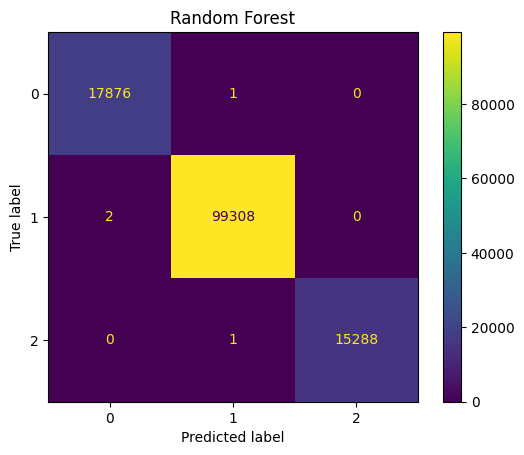

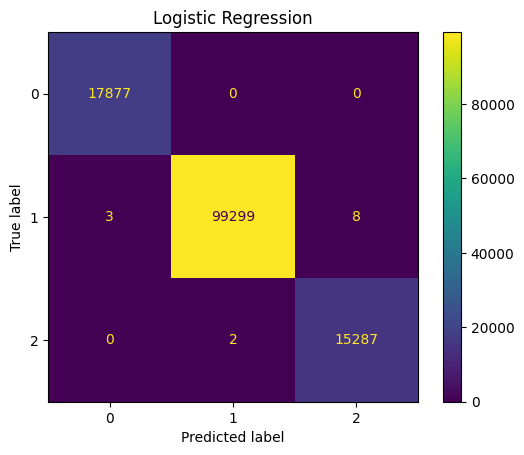

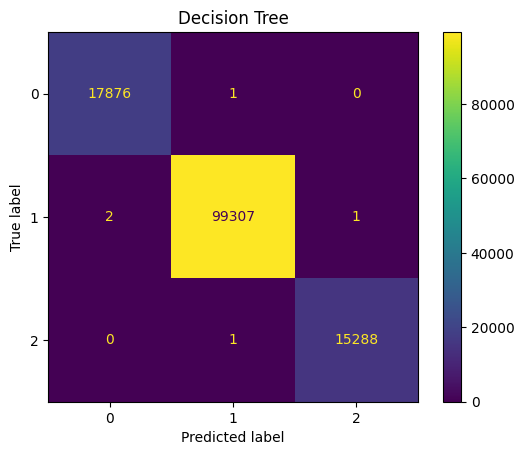

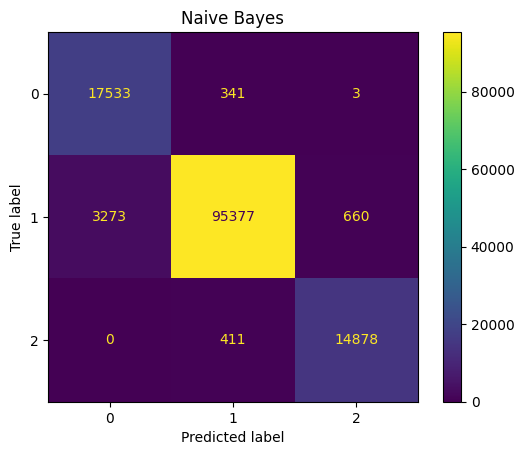

In [65]:
plot_confusion(model, X_test, y_test, "Random Forest")
plot_confusion(lr_model, X_test, y_test, "Logistic Regression")
plot_confusion(dt_model, X_test, y_test, "Decision Tree")
plot_confusion(nb_model, X_test, y_test, "Naive Bayes")